In [1]:
# import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
runs = [100, 1_000, 1_000_0, 1_000_00]#, 1_000_000]

a1_0 = 100
b_a1 = 2
t1 = 10
d_a1 = 3.8*10**(-4)
T_a1 = 10

MI_b_a1 = np.zeros((len(runs),len(stat_names)))

### (1) Compute mutual information as a function of dataset size

In [3]:
run_count = 0

for run in runs:
    b_a1s = np.random.uniform(0.1*b_a1, 10*b_a1, size = run) 
    t1s = [t1]
    d_a1s = [d_a1]
    a1_0s = [a1_0]

    run_data_b_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(b_a1s)/8))(delayed(sum_sim)(a1_0, b_a1, t1, d_a1)
                                                  for a1_0 in a1_0s
                                                  for b_a1 in b_a1s
                                                  for t1 in t1s
                                                  for d_a1 in d_a1s))
    
    for i in range(run_data_b_a1.shape[1]):
        MI_b_a1[run_count, i] = calc_MI(run_data_b_a1[:,1],run_data_b_a1[:,i])
    
    run_count += 1
    
#np.save('compute-MI.npy',run_data_b_a1)

Text(0.5, 0.98, 'MI increases with additional simulation runs')

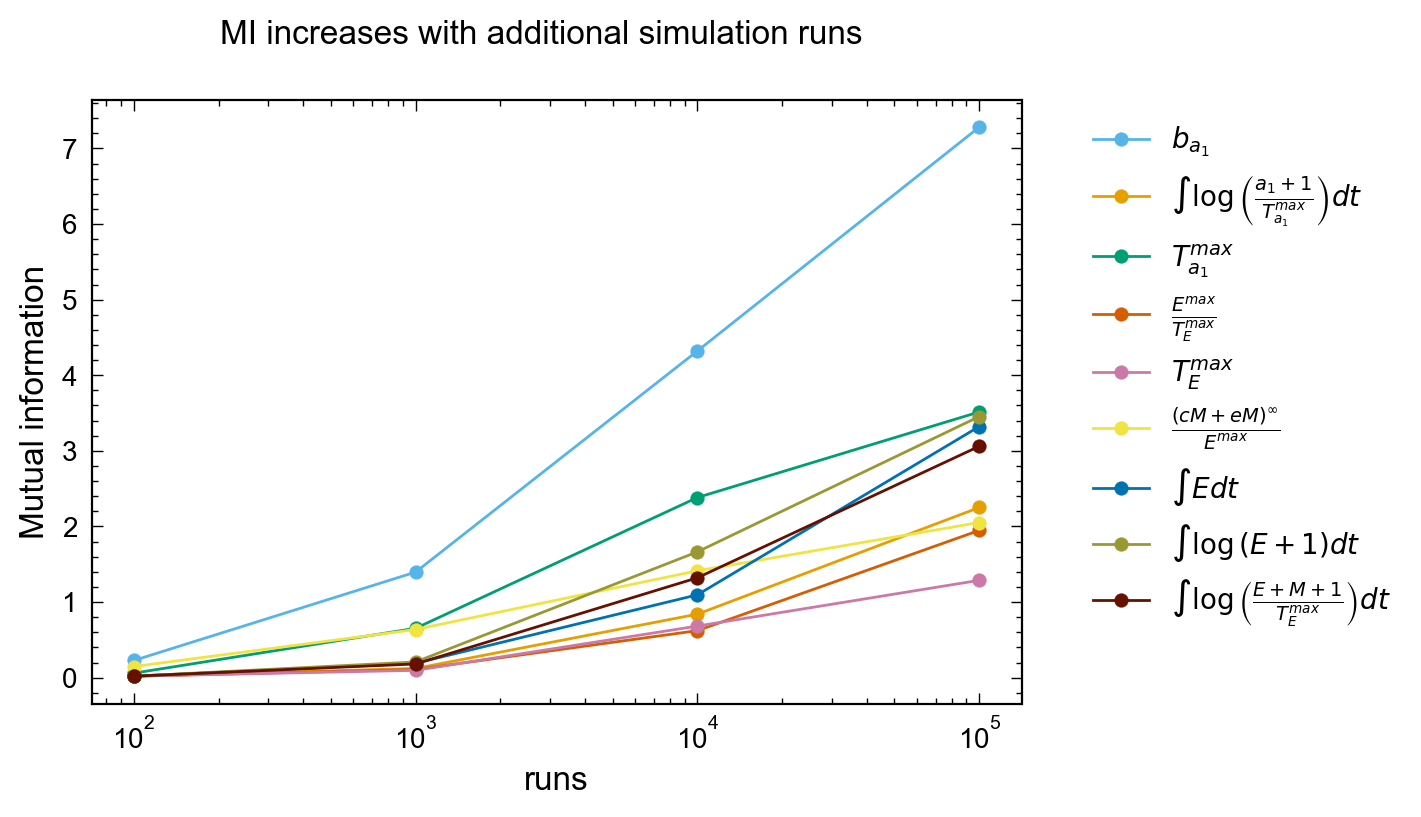

In [4]:
plt.plot(runs, MI_b_a1[:,np.hstack(([1],np.arange(4,len(stat_names))))], 'o-', label = np.concatenate(([stat_names[1]],stat_names[4:]), axis = None))
plt.xlabel("runs")
plt.ylabel("Mutual information")
plt.semilogx()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle('MI increases with additional simulation runs')
#plt.savefig('MI-scales-with-runs.png', dpi=150, bbox_inches="tight")

[]

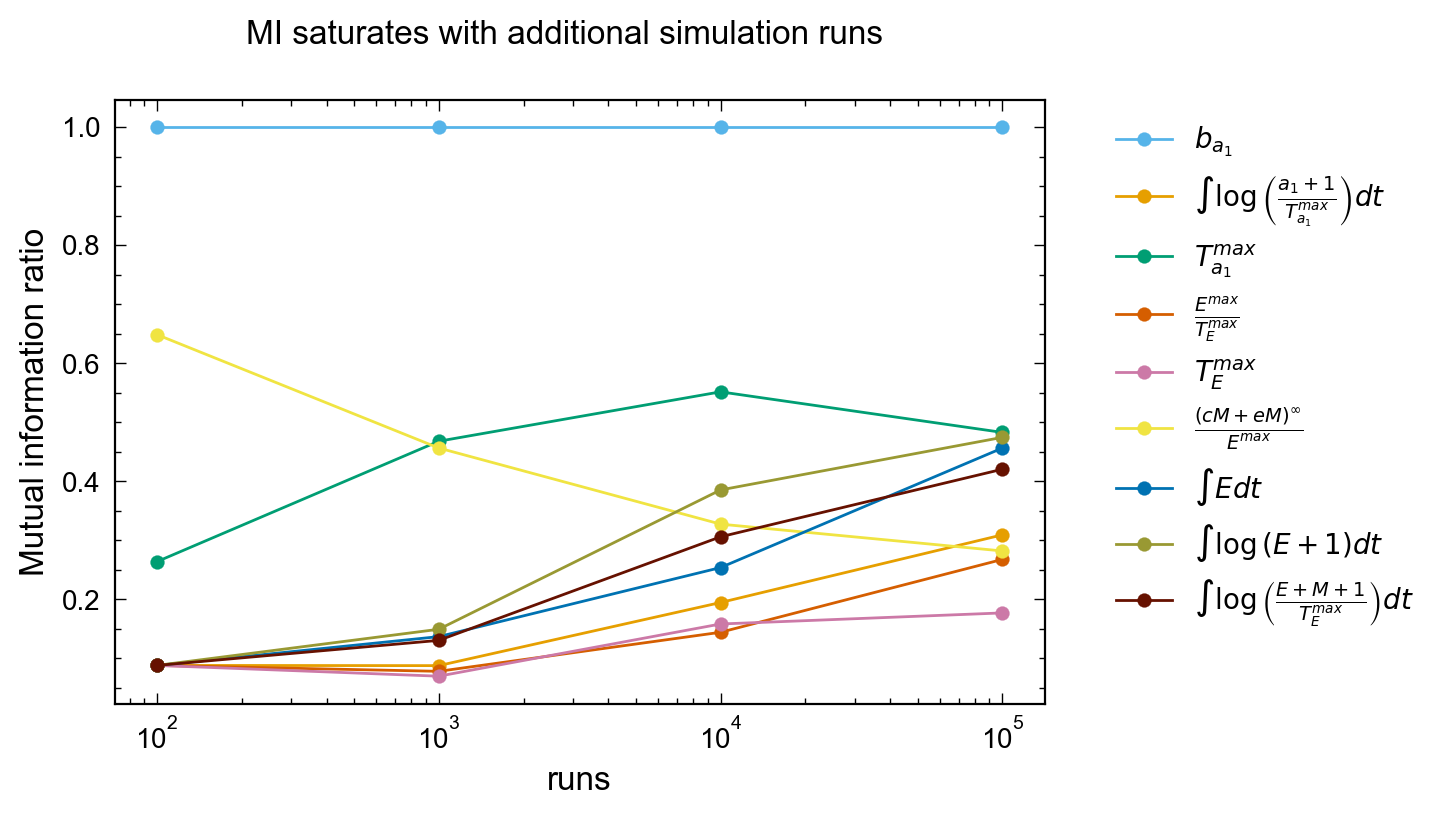

In [5]:
MI_b_a1_frac = np.zeros((len(runs),len(stat_names)))
for i in np.arange(len(runs)):
    MI_b_a1_frac[i,:] = MI_b_a1[i,:]/MI_b_a1[i,1]
 

plt.plot(runs, MI_b_a1_frac[:,np.hstack(([1],np.arange(4,len(stat_names))))], 'o-',label = np.concatenate(([stat_names[1]],stat_names[4:]), axis = None))
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.xlabel("runs")
plt.suptitle('MI saturates with additional simulation runs')
plt.ylabel("Mutual information ratio")
plt.semilogx()
#plt.savefig('MI-stabilizes-with-runs.png', dpi=150, bbox_inches="tight")

### (2) Compute mutual information as a function of bin number

In [6]:
bin_nums = [10,100, 500, 1000, 10000]
MI_b_a1_bins = np.zeros((len(bin_nums),len(stat_names)))
run_count = 0
run_data_b_a1 = np.load('compute-MI.npy')

for bin_num in bin_nums:

    for i in range(run_data_b_a1.shape[1]):
        MI_b_a1_bins[run_count, i] = calc_MI(run_data_b_a1[:,1],run_data_b_a1[:,i], bin_num)
    
    run_count += 1

Text(0.5, 0.98, 'There is an optimal bin size for MI')

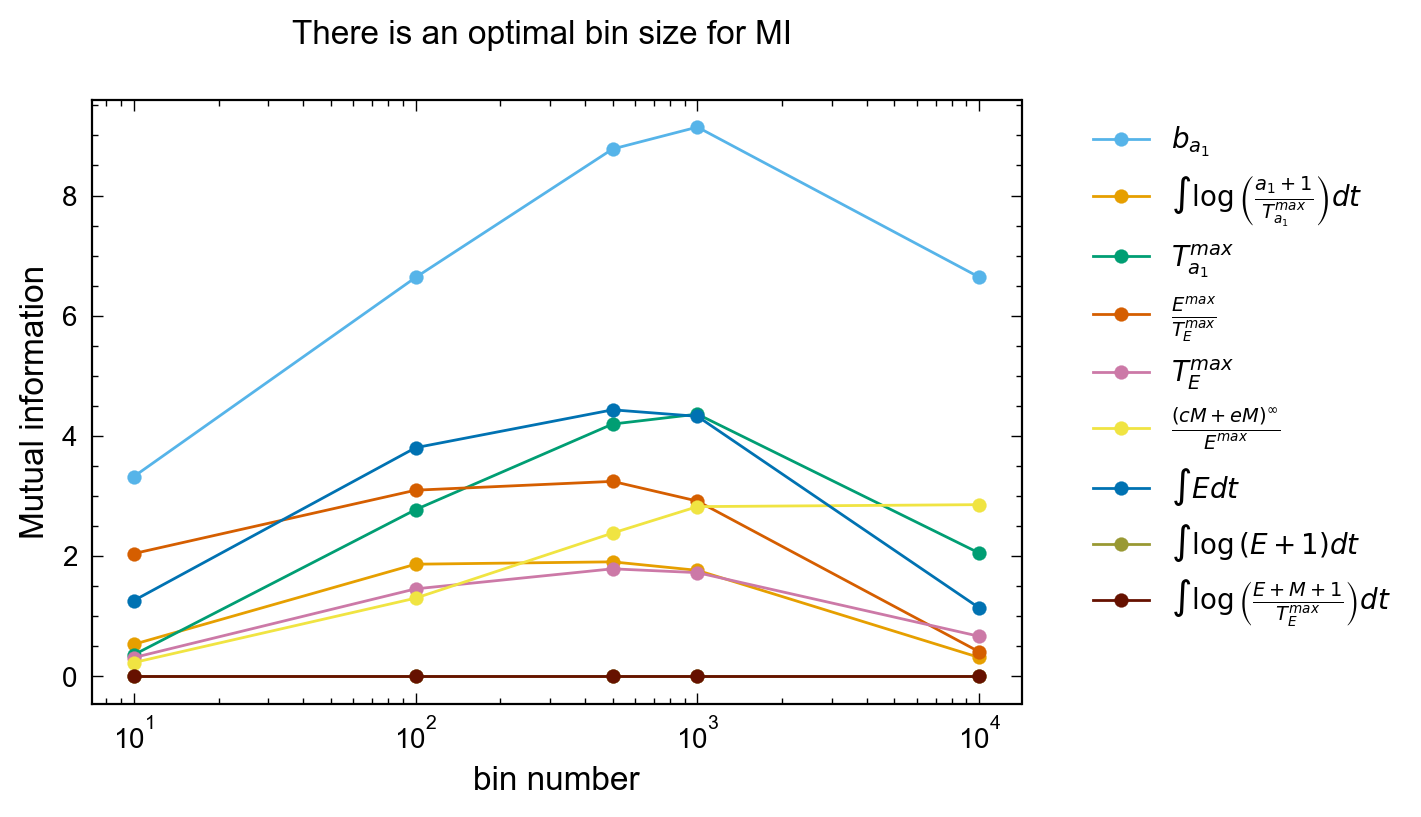

In [7]:
plt.plot(bin_nums, MI_b_a1_bins[:,np.hstack(([1],np.arange(4,len(stat_names))))], 'o-', label = np.concatenate(([stat_names[1]],stat_names[4:]), axis = None))
plt.xlabel("bin number")
plt.ylabel("Mutual information")
plt.semilogx()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle('There is an optimal bin size for MI')
#plt.savefig('MI-varies-with-bin-nums.png', dpi=150, bbox_inches="tight")